In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

import os
import zipfile
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

In [2]:
file_path = 'https://www.dropbox.com/scl/fi/hsh5kfc52hv57pkjq3crp/scholastic_travel.csv?rlkey=lzmscfrwl7wfrlgxdhc469zss&st=0c5kf8b9&dl=1'
data = pd.read_csv(file_path)

data.head()

,ProgramCode,FromGrade,ToGrade,GroupState,IsNonAnnual,Days,TravelType,DepartureDate,ReturnDate,DepositDate,...,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,SingleGradeTripFlag,FPPtoSchoolenrollment,FPPtoPAX,NumofNonFPPPAX,SchoolSizeIndicator,RetainedLabel
0,HS,4,4,CA,0,1,A,1/14/11,1/14/11,8/30/10,...,K,Elementary,K->Elementary,H,1,0.063646,0.936508,4,L,Retained
1,HC,8,8,AZ,0,7,A,1/14/11,1/21/11,11/15/09,...,Middle,Middle,Middle->Middle,H,1,0.025882,0.880000,3,L,Retained
2,HD,8,8,FL,0,3,A,1/15/11,1/17/11,10/15/10,...,Middle,Middle,Middle->Middle,H,1,0.025131,0.888889,3,L,Retained
3,HN,9,12,Other,1,3,B,1/15/11,1/17/11,1/7/11,...,Undefined,Undefined,Undefined->Undefined,H,0,0.000000,1.000000,0,FIXED_NA,Churned
4,HD,6,8,FL,0,6,Other,1/16/11,1/21/11,9/30/10,...,Middle,Middle,Middle->Middle,H,0,0.112500,0.910112,8,M-L,Churned


## Data exploration and pre-processing

In [3]:
data.columns[data.isnull().any()]

Index([], dtype='object')

In [4]:
data.shape

(2389, 55)

In [5]:
data["RetainedLabel"].value_counts()

,count
RetainedLabel,
Retained,1451
Churned,938


In [6]:
mapping = {'Retained': 0, 'Churned': 1}
data['ChurnLabel'] = data['RetainedLabel'].map(mapping)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ProgramCode                     2389 non-null   object 
 1   FromGrade                       2389 non-null   int64  
 2   ToGrade                         2389 non-null   int64  
 3   GroupState                      2389 non-null   object 
 4   IsNonAnnual                     2389 non-null   int64  
 5   Days                            2389 non-null   int64  
 6   TravelType                      2389 non-null   object 
 7   DepartureDate                   2389 non-null   object 
 8   ReturnDate                      2389 non-null   object 
 9   DepositDate                     2389 non-null   object 
 10  SpecialPay                      2389 non-null   object 
 11  Tuition                         2389 non-null   int64  
 12  FRPActive                       23

In [8]:
data["LastMeeting"]

,LastMeeting
0,8/12/10
1,8/27/10
2,9/13/10
3,1/1/10
4,8/24/10
...,...
2384,1/1/10
2385,10/7/10
2386,1/1/10
2387,9/16/10


In [9]:
date_cols = [
    "DepartureDate",
    "ReturnDate",
    "DepositDate",
    "EarlyRPL",
    "LatestRPL",
    "InitialSystemDate",
    "FirstMeeting",
    "LastMeeting"
]

for col in date_cols:
    data[col] = pd.to_datetime(data[col], format="%m/%d/%y", errors="coerce")

data["days_to_departure"] = (data["DepartureDate"] - data["DepositDate"]).dt.days
data["planning_window"] = (data["DepartureDate"] - data["InitialSystemDate"]).dt.days
data["meeting_span"] = (data["LastMeeting"] - data["FirstMeeting"]).dt.days
data["deposit_to_first_meeting"] = (data["FirstMeeting"] - data["DepositDate"]).dt.days

In [10]:
data["ChurnLabel"]

,ChurnLabel
0,0
1,0
2,0
3,1
4,1
...,...
2384,1
2385,0
2386,0
2387,0


In [11]:
data["grade_range"] = data["ToGrade"] - data["FromGrade"]

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ProgramCode                     2389 non-null   object        
 1   FromGrade                       2389 non-null   int64         
 2   ToGrade                         2389 non-null   int64         
 3   GroupState                      2389 non-null   object        
 4   IsNonAnnual                     2389 non-null   int64         
 5   Days                            2389 non-null   int64         
 6   TravelType                      2389 non-null   object        
 7   DepartureDate                   2389 non-null   datetime64[ns]
 8   ReturnDate                      2389 non-null   datetime64[ns]
 9   DepositDate                     2389 non-null   datetime64[ns]
 10  SpecialPay                      2389 non-null   object        
 11  Tuit

# KNN Model

In [13]:
df_knn = data.copy()

In [14]:
# Ensure features and labels are defined
features = ["ToGrade", "Tuition", "Days", "TotalSchoolEnrollment"]
X = df_knn[features]
y = df_knn["ChurnLabel"]

# This is the line that defines X_train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


KNN Classification Report:
               precision    recall  f1-score   support

    Retained       0.64      0.82      0.72       274
     Churned       0.61      0.37      0.46       204

    accuracy                           0.63       478
   macro avg       0.63      0.60      0.59       478
weighted avg       0.63      0.63      0.61       478

Area under ROC curve (AUC): 0.6599


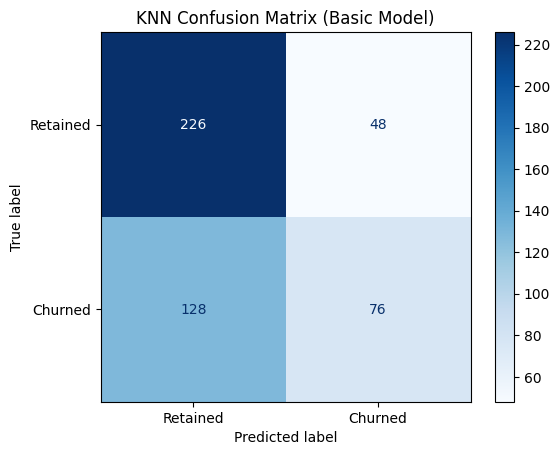

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Define the steps
steps = [
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=20))
]

# 2. Create and Fit the pipeline
pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

# 3. Predict using the RAW X_test (The pipeline scales it for you!)
y_pred = pipeline.predict(X_test)
knn_y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# 4. Evaluation
print("\nKNN Classification Report:\n",
      classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

print(f"Area under ROC curve (AUC): {roc_auc_score(y_test, knn_y_pred_proba):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
# Added display_labels so you know which box is 'Churned'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(cmap='Blues')
plt.title('KNN Confusion Matrix (Basic Model)') # Fixed the closing parenthesis here
plt.show()

## Adding PCA this time with all numeric columns only


KNN Classification Report:
               precision    recall  f1-score   support

    Retained       0.69      0.91      0.78       274
     Churned       0.78      0.46      0.58       204

    accuracy                           0.72       478
   macro avg       0.74      0.68      0.68       478
weighted avg       0.73      0.72      0.70       478

Area under ROC curve (AUC): 0.8060505223987406


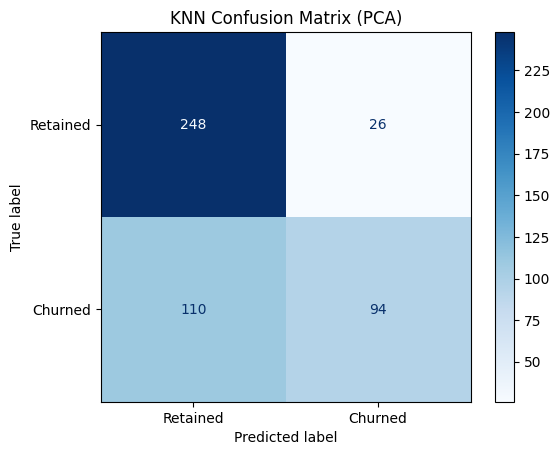

In [16]:
from sklearn.decomposition import PCA

X = df_knn.drop(columns=["RetainedLabel", "ChurnLabel"])
y = df_knn["ChurnLabel"]

X = X.select_dtypes(include=["number"])

# This is the line that defines X_train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Define the steps
steps = [
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=.95)),
    ('knn', KNeighborsClassifier(n_neighbors=20))
]

# 2. Create and Fit the pipeline
pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

# 3. Predict using the RAW X_test
# The pipeline handles the scaling for you automatically!
y_pred = pipeline.predict(X_test)
knn_y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# 4. Evaluation
print("\nKNN Classification Report:\n",
      classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
print("Area under ROC curve (AUC):", roc_auc_score(y_test, knn_y_pred_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('KNN Confusion Matrix (PCA)')
plt.show()

## Randomized Grid Search with PCA


Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 64, 'knn__weights': 'distance', 'pca__n_components': 0.95}
Test ROC-AUC: 0.8176

Classification Report:

              precision    recall  f1-score   support

    Retained       0.68      0.92      0.79       274
     Churned       0.81      0.43      0.56       204

    accuracy                           0.71       478
   macro avg       0.74      0.67      0.67       478
weighted avg       0.74      0.71      0.69       478



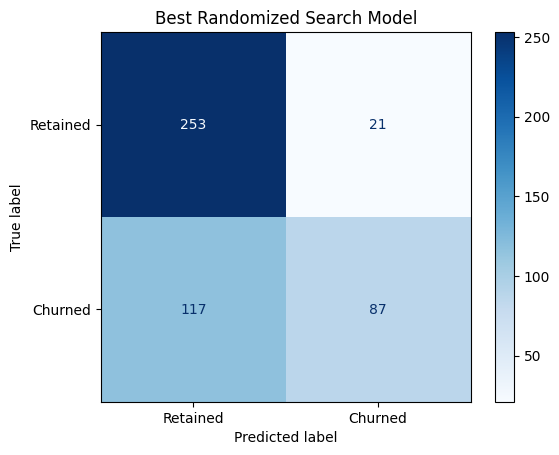

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
from scipy.stats import randint
import matplotlib.pyplot as plt

# 1. Define Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

# 2. Parameter distributions
param_dist = {
    'pca__n_components': [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.98],
    'knn__n_neighbors': randint(3, 75),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}


random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    refit='roc_auc',   # model selected based on ROC-AUC
    n_jobs=-1,
    random_state=42
)

# 4. Fit
random_search.fit(X_train, y_train)

# 5. Best model
best_model = random_search.best_estimator_

# 6. Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 7. Evaluation
print(f"Best Parameters: {random_search.best_params_}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

# 8. Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Retained", "Churned"],
    cmap="Blues"
)

plt.title("Best Randomized Search Model")
plt.show()

## Manually Choosing Features, Random grid Search

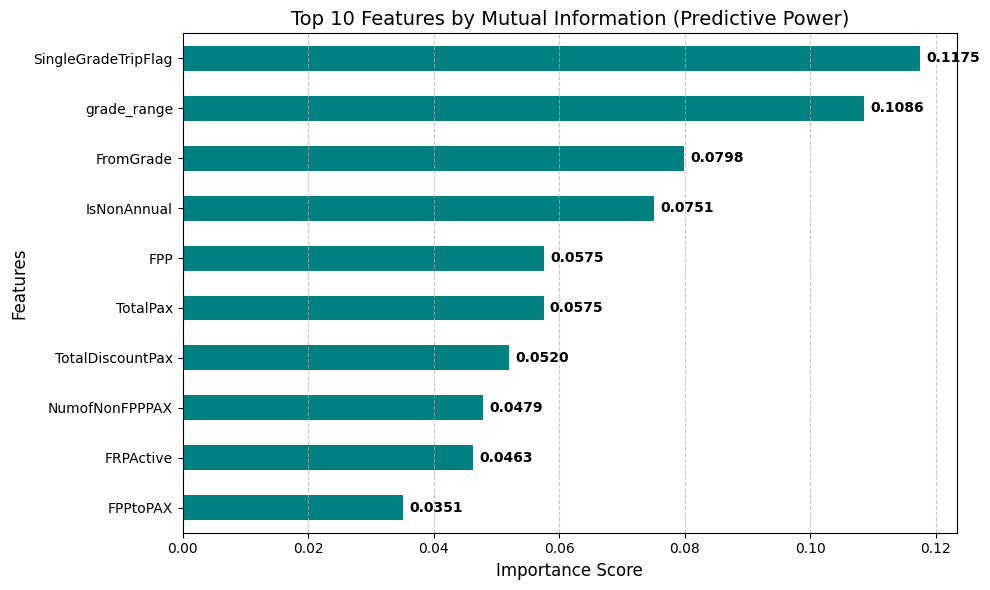

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# --- 1. Calculate & Sort (From previous steps) ---
importances = mutual_info_classif(X_train, y_train, random_state=42)
feat_importances = pd.Series(importances, index=X_train.columns)
feat_importances_sorted = feat_importances.sort_values(ascending=False)

# --- 2. Select the Top 10 ---
top_10_features = feat_importances_sorted.head(10)
top_features_list = top_10_features.index.tolist() # Your list for later use

# --- 3. Create the Plot ---
plt.figure(figsize=(10, 6))
# Using barh (horizontal) is great for long feature names
top_10_features.plot(kind='barh', color='teal')

# --- 4. Add labels and title ---
plt.title('Top 10 Features by Mutual Information (Predictive Power)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# --- 5. Invert y-axis & Grid ---
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)

# --- 6. Add Value Labels (Optional but helpful) ---
for i, v in enumerate(top_10_features):
    plt.text(v + 0.001, i, f'{v:.4f}', color='black', va='center', fontweight='bold')

# --- 7. Show/Save ---
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Now you can use this for your model:
# X_train_selected = X_train[top_features_list]

In [19]:
X = df_knn[top_features_list]
y = df_knn["ChurnLabel"]

# Re-run your train_test_split with this subset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 47, 'knn__weights': 'uniform'}
Test ROC-AUC: 0.8194

Classification Report:

              precision    recall  f1-score   support

    Retained       0.77      0.85      0.81       274
     Churned       0.76      0.66      0.71       204

    accuracy                           0.77       478
   macro avg       0.77      0.75      0.76       478
weighted avg       0.77      0.77      0.77       478



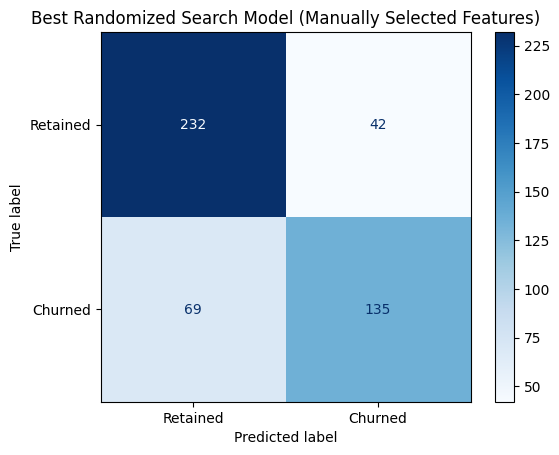

In [20]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_dist = {
    'knn__n_neighbors': randint(3, 75),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

best_model = random_search.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Best Parameters: {random_search.best_params_}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Retained", "Churned"],
    cmap="Blues"
)

plt.title("Best Randomized Search Model (Manually Selected Features)")
plt.show()

## Mutual Information Features and GridSearch (not random)

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 41, 'knn__weights': 'uniform'}
Test ROC-AUC: 0.8172

Classification Report:

              precision    recall  f1-score   support

    Retained       0.77      0.85      0.81       274
     Churned       0.76      0.66      0.71       204

    accuracy                           0.77       478
   macro avg       0.77      0.75      0.76       478
weighted avg       0.77      0.77      0.77       478



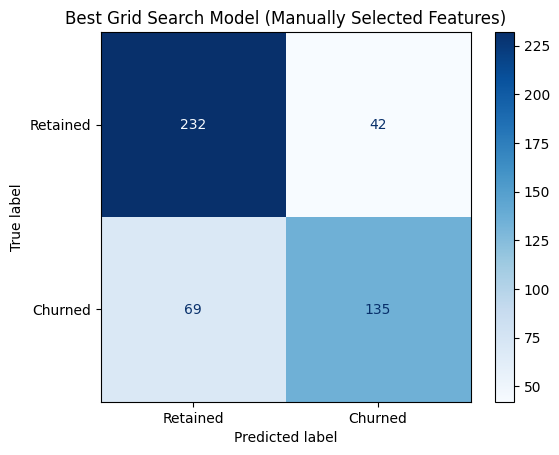

In [21]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 11, 21, 31, 41, 51, 61, 71],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Retained", "Churned"],
    cmap="Blues"
)

plt.title("Best Grid Search Model (Manually Selected Features)")
plt.show()

*Encoding used here: `RetainedLabel` is mapped to a binary target where **1 = Retained** (returned next year) and **0 = Churned**. Metrics are reported for the positive class = Retained.*

# Tree-Based Model: Random Forest (Retention Prediction)

**Goal:** predict next-year churn (`RetainedLabel` = `Retained` vs `Churned`) using a tree-based model, evaluate it (accuracy / precision / recall / AUC), tune hyperparameters, and generate the required `prediction_submission.csv`.

## 1) Load data (labeled + unlabeled)

If you uploaded the zip (`classification_project_files-1.zip`) into Colab or your working directory, this will extract it and load the CSVs.


In [22]:
# --- If the zip exists locally, extract it ---
ZIP_PATH = "classification_project_files-1.zip"
EXTRACT_DIR = "classification_project_files"

if os.path.exists(ZIP_PATH) and not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")

# --- Preferred local paths (after extracting the zip) ---
DATA_PATH_LOCAL = os.path.join(EXTRACT_DIR, "scholastic_travel.csv")
PRED_PATH_LOCAL = os.path.join(EXTRACT_DIR, "scholastic_travel_predictions.csv")

# --- Fallback: instructor dropbox links (only used if local files are missing) ---
DATA_PATH_FALLBACK = "https://www.dropbox.com/scl/fi/hsh5kfc52hv57pkjq3crp/scholastic_travel.csv?rlkey=lzmscfrwl7wfrlgxdhc469zss&dl=1"
PRED_PATH_FALLBACK = "https://www.dropbox.com/scl/fi/hveyqinjaurpm2e1s5uh2/scholastic_travel_predictions.csv?rlkey=3sx0cjmaubjafwripmcsfhktd&dl=1"

DATA_PATH = DATA_PATH_LOCAL if os.path.exists(DATA_PATH_LOCAL) else DATA_PATH_FALLBACK
PRED_PATH = PRED_PATH_LOCAL if os.path.exists(PRED_PATH_LOCAL) else PRED_PATH_FALLBACK

df_raw = pd.read_csv(DATA_PATH)
df_pred_raw = pd.read_csv(PRED_PATH)

print("Labeled data shape:", df_raw.shape)
print("Unlabeled data shape:", df_pred_raw.shape)
df_raw.head()


Labeled data shape: (2389, 55)
Unlabeled data shape: (479, 55)


,ProgramCode,FromGrade,ToGrade,GroupState,IsNonAnnual,Days,TravelType,DepartureDate,ReturnDate,DepositDate,...,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,SingleGradeTripFlag,FPPtoSchoolenrollment,FPPtoPAX,NumofNonFPPPAX,SchoolSizeIndicator,RetainedLabel
0,HS,4,4,CA,0,1,A,1/14/11,1/14/11,8/30/10,...,K,Elementary,K->Elementary,H,1,0.063646,0.936508,4,L,Retained
1,HC,8,8,AZ,0,7,A,1/14/11,1/21/11,11/15/09,...,Middle,Middle,Middle->Middle,H,1,0.025882,0.880000,3,L,Retained
2,HD,8,8,FL,0,3,A,1/15/11,1/17/11,10/15/10,...,Middle,Middle,Middle->Middle,H,1,0.025131,0.888889,3,L,Retained
3,HN,9,12,Other,1,3,B,1/15/11,1/17/11,1/7/11,...,Undefined,Undefined,Undefined->Undefined,H,0,0.000000,1.000000,0,FIXED_NA,Churned
4,HD,6,8,FL,0,6,Other,1/16/11,1/21/11,9/30/10,...,Middle,Middle,Middle->Middle,H,0,0.112500,0.910112,8,M-L,Churned


## 2) Feature engineering

Random forests can handle lots of predictors, including one-hot-encoded categoricals.

Feature engineering used here:
- Parse date columns and extract **month / day-of-week / year**
- Create time deltas like **days_to_departure**, **planning_window**, **meeting_span**
- Add **grade_range** (`ToGrade - FromGrade`)
- Add simple rates: `discount_pax_rate`, `cancel_pax_rate`, `fpp_rate`
- Drop raw datetime columns after creating numeric features


In [23]:
def feature_engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    date_cols = [
        "DepartureDate", "ReturnDate", "DepositDate",
        "EarlyRPL", "LatestRPL", "InitialSystemDate",
        "FirstMeeting", "LastMeeting"
    ]

    # Parse to datetime + extract components
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format="%m/%d/%y", errors="coerce")
            df[f"{col}_month"] = df[col].dt.month
            df[f"{col}_dow"] = df[col].dt.dayofweek
            df[f"{col}_year"] = df[col].dt.year

    # Time deltas
    if {"DepartureDate", "DepositDate"}.issubset(df.columns):
        df["days_to_departure"] = (df["DepartureDate"] - df["DepositDate"]).dt.days
    if {"DepartureDate", "InitialSystemDate"}.issubset(df.columns):
        df["planning_window"] = (df["DepartureDate"] - df["InitialSystemDate"]).dt.days
    if {"LastMeeting", "FirstMeeting"}.issubset(df.columns):
        df["meeting_span"] = (df["LastMeeting"] - df["FirstMeeting"]).dt.days
    if {"FirstMeeting", "DepositDate"}.issubset(df.columns):
        df["deposit_to_first_meeting"] = (df["FirstMeeting"] - df["DepositDate"]).dt.days
    if {"ReturnDate", "DepartureDate"}.issubset(df.columns):
        df["trip_length_from_dates"] = (df["ReturnDate"] - df["DepartureDate"]).dt.days

    # Grade range
    if {"ToGrade", "FromGrade"}.issubset(df.columns):
        df["grade_range"] = df["ToGrade"] - df["FromGrade"]

    # Simple rates (guard division by zero)
    if {"TotalDiscountPax", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["discount_pax_rate"] = df["TotalDiscountPax"] / denom

    if {"CancelledPax", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["cancel_pax_rate"] = df["CancelledPax"] / denom

    if {"FPP", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["fpp_rate"] = df["FPP"] / denom

    # Drop raw datetime columns (keep engineered numeric components)
    for col in date_cols:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    return df


df = feature_engineer(df_raw)

y = df_raw["RetainedLabel"].map({"Churned": 0, "Retained": 1})
X = df.drop(columns=["RetainedLabel"], errors="ignore")

print("X shape after feature engineering:", X.shape)
y.value_counts()


X shape after feature engineering: (2389, 79)


,count
RetainedLabel,
1,1451
0,938


## 3) Train/test split + preprocessing pipeline

We use a `ColumnTransformer` so:
- numeric columns → median imputation
- categorical columns → most-frequent imputation + one-hot encoding (`handle_unknown="ignore"`)


In [24]:
# Identify categorical vs numeric predictors
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1911, 79) Test: (478, 79)


## 4) Utility: evaluate metrics

We report:
- **Accuracy**
- **Precision**
- **Recall**
- **AUC** (ROC-AUC; uses predicted probabilities)


In [25]:
def evaluate_binary(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_proba),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


## 5) Baseline Random Forest

A solid baseline for tabular classification is:

- `n_estimators=300`
- `class_weight="balanced_subsample"` (helps if classes are imbalanced)
- `max_features="sqrt"`


In [26]:
baseline_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_features="sqrt",
)

baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("rf", baseline_rf)
])

baseline_model.fit(X_train, y_train)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_binary(y_test, baseline_proba)

baseline_metrics


{'accuracy': 0.8138075313807531,
 'precision': 0.8361204013377926,
 'recall': 0.8620689655172413,
 'auc': np.float64(0.8615278796771826),
 'confusion_matrix': array([[139,  49],
        [ 40, 250]])}

## 6) Hyperparameter tuning (small manual log)

Instead of an expensive CV search, this runs **7** reasonable parameter sets quickly and logs test-set metrics.

You can add more rows/configurations if you want (e.g., vary `max_depth`, `min_samples_leaf`, `max_features`).


In [27]:
configs = [
    {"config":"baseline_balanced", "n_estimators":300, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"depth12_leaf2",     "n_estimators":300, "max_depth":12,   "min_samples_leaf":2, "min_samples_split":4, "max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"more_regularized",  "n_estimators":300, "max_depth":10,   "min_samples_leaf":5, "min_samples_split":10,"max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"unweighted",        "n_estimators":300, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":True, "class_weight":None},
    {"config":"log2_features",     "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"log2", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"half_features",     "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":0.5,    "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"no_bootstrap",      "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":False,"class_weight":"balanced_subsample"},
]

rows = []
for cfg in configs:
    rf = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_split=cfg["min_samples_split"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"],
        bootstrap=cfg["bootstrap"],
        class_weight=cfg["class_weight"],
        random_state=42,
        n_jobs=-1
    )

    model = Pipeline([("preprocess", preprocess), ("rf", rf)])
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    m = evaluate_binary(y_test, proba)

    rows.append({
        **cfg,
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "auc": m["auc"],
    })

rf_log = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
rf_log


,config,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features,bootstrap,class_weight,accuracy,precision,recall,auc
5,half_features,250,NaN,1,2,0.5,True,balanced_subsample,0.817992,0.830619,0.879310,0.868048
3,unweighted,300,NaN,1,2,sqrt,True,None,0.815900,0.843537,0.855172,0.863756
6,no_bootstrap,250,NaN,1,2,sqrt,False,balanced_subsample,0.815900,0.843537,0.855172,0.859950
0,baseline_balanced,300,NaN,1,2,sqrt,True,balanced_subsample,0.813808,0.836120,0.862069,0.861528
4,log2_features,250,NaN,1,2,log2,True,balanced_subsample,0.811715,0.831126,0.865517,0.855163
1,depth12_leaf2,300,12.0,2,4,sqrt,True,balanced_subsample,0.799163,0.839161,0.827586,0.860216
2,more_regularized,300,10.0,5,10,sqrt,True,balanced_subsample,0.782427,0.839416,0.793103,0.857080


## 7) Fit the best RF + inspect confusion matrix and feature importance

We’ll pick the best row by **accuracy** from `rf_log`, refit it, then:
- show confusion matrix
- plot top importances (from `feature_importances_`)


In [28]:
# Pick best hyperparameters by test accuracy (from the log above)
best_row = rf_log.iloc[0].to_dict()
best_row


{'config': 'half_features',
 'n_estimators': 250,
 'max_depth': nan,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'max_features': 0.5,
 'bootstrap': True,
 'class_weight': 'balanced_subsample',
 'accuracy': 0.8179916317991632,
 'precision': 0.8306188925081434,
 'recall': 0.8793103448275862,
 'auc': 0.868048422597212}

In [29]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_row["n_estimators"]),
    max_depth=None if pd.isna(best_row["max_depth"]) else int(best_row["max_depth"]),
    min_samples_split=int(best_row["min_samples_split"]),
    min_samples_leaf=int(best_row["min_samples_leaf"]),
    max_features=best_row["max_features"],
    bootstrap=bool(best_row["bootstrap"]),
    class_weight=best_row["class_weight"],
    random_state=42,
    n_jobs=-1
)

best_model = Pipeline([
    ("preprocess", preprocess),
    ("rf", best_rf)
])

best_model.fit(X_train, y_train)
best_proba = best_model.predict_proba(X_test)[:, 1]
best_metrics = evaluate_binary(y_test, best_proba)

best_metrics


{'accuracy': 0.8179916317991632,
 'precision': 0.8306188925081434,
 'recall': 0.8793103448275862,
 'auc': np.float64(0.868048422597212),
 'confusion_matrix': array([[136,  52],
        [ 35, 255]])}

In [30]:
cm = best_metrics["confusion_matrix"]
cm


array([[136,  52],
       [ 35, 255]])

,feature,importance
22,SingleGradeTripFlag,0.113937
55,grade_range,0.081060
2,IsNonAnnual,0.064375
129,SPRNewExisting_EXISTING,0.036963
16,FPP,0.036643
130,SPRNewExisting_NEW,0.031506
51,planning_window,0.030291
17,TotalPax,0.029754
13,TotalSchoolEnrollment,0.026536
53,deposit_to_first_meeting,0.024043


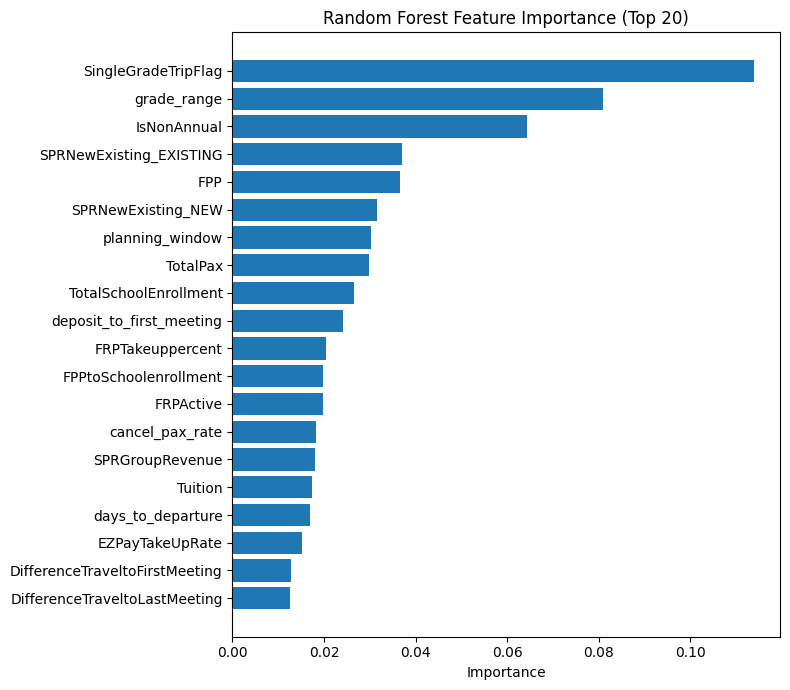

In [31]:
# ---- Feature importance (top 20) ----
pre = best_model.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

feature_names = np.concatenate([
    np.array(num_cols, dtype=object),
    ohe.get_feature_names_out(cat_cols)
])

importances = best_model.named_steps["rf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

top_k = 20
display(imp_df.head(top_k))

plt.figure(figsize=(8, 7))
plt.barh(imp_df.head(top_k)["feature"][::-1], imp_df.head(top_k)["importance"][::-1])
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# New Classification Method: Gaussian Process Classification

Supervised Learning Documentation

[See scikit-learn's Supervised Learning Documentation for more information about other classification methods](https://scikit-learn.org/stable/supervised_learning.html)

In [32]:
# Load an CSV file
file_path = 'https://www.dropbox.com/scl/fi/hsh5kfc52hv57pkjq3crp/scholastic_travel.csv?rlkey=lzmscfrwl7wfrlgxdhc469zss&st=0c5kf8b9&dl=1'
data = pd.read_csv(file_path)

data.head()

mapping = {'Retained': 0, 'Churned': 1}
data['RetainedLabel'] = data['RetainedLabel'].map(mapping)

data[[
    "DepartureDate",
    "ReturnDate",
    "DepositDate",
    "EarlyRPL",
    "LatestRPL",
    "InitialSystemDate",
    "FirstMeeting",
    "LastMeeting"]
]

for col in date_cols:
    data[col] = pd.to_datetime(data[col], format="%m/%d/%y", errors="coerce")

data["days_to_departure"] = (data["DepartureDate"] - data["DepositDate"]).dt.days
data["planning_window"] = (data["DepartureDate"] - data["InitialSystemDate"]).dt.days
data["meeting_span"] = (data["LastMeeting"] - data["FirstMeeting"]).dt.days
data["deposit_to_first_meeting"] = (data["FirstMeeting"] - data["DepositDate"]).dt.days

In [33]:
# Make a copy of data
data_feature_section = data.copy()

In [34]:
# Remove datetime columns
data_feature_section_mi = data_feature_section.select_dtypes(exclude=['datetime'])

# Create dummy variables for categorical variables
data_feature_section_mi = pd.get_dummies(data_feature_section_mi, drop_first=True)
# Define features (X) and target (y) of the whole dataset
X = data_feature_section_mi.drop("RetainedLabel", axis=1)
y = data_feature_section_mi["RetainedLabel"]

In [35]:
# Filter features by mutual information
# MI measures the amount of shared information between two random variables
mi = mutual_info_classif(X, y)

# Combine scores with column names
mi_series = pd.Series(mi, index=X.columns)

# Sort features by importance (descending)
mi_series = mi_series.sort_values(ascending=False)

# View top 10 features
print(mi_series.head(10))

IsNonAnnual            0.099147
SingleGradeTripFlag    0.097734
FromGrade              0.084759
SPRNewExisting_NEW     0.080471
NumofNonFPPPAX         0.059353
FPP                    0.054301
TotalPax               0.050377
FRPActive              0.049757
FRPTakeuppercent       0.038199
CRMSegment             0.036392
dtype: float64


create a list of features that I would like to explore visually:
* days_to_departure
* planning_window
* meeting_span
* IncomeLevel
* TotalSchoolEnrollment
* DepartureMonth
* IsNonAnnual
* Tuition
* SingleGradeTripFlag
* SPRNewExisting
* FPP
* FRPActive

In [36]:
#functions to create visiualization to compare the features against the RetainedLabel
#function to create boxplot
def boxplot_retention(feature, feature_label):

  sns.boxplot(x='RetainedLabel', y=feature, data=data_feature_section)
  plt.title(feature_label + ' by Retention Category')
  plt.show()

#function to create histogram
def histplot_retention(feature, feature_label):

  sns.histplot(data=data_feature_section, x=feature, hue='RetainedLabel', element='step', stat='density', common_norm=False)
  plt.title(feature_label + ' Distribution by Retention Category')
  plt.show()

def barplot_bin_retention(feature, feature_label, bins_num):

  # Bin days_to_departure
  data_feature_section['bins'] = pd.cut(data_feature_section[feature], bins=bins_num)

  # Compute retention rate per bin
  retention_rate = data_feature_section.groupby('bins')['RetainedLabel'].mean().reset_index()

  # Compute overall average retention
  overall_avg = data_feature_section['RetainedLabel'].mean()

  # Plot barplot
  sns.barplot(x='bins', y='RetainedLabel', data=retention_rate)
  plt.xticks(rotation=45)
  plt.ylabel('Retention Rate')
  plt.title('Retention Rate by ' + feature_label)

  # Add average line
  plt.axhline(overall_avg, color='red', linestyle='--', label=f'Overall Avg: {overall_avg:.2f}')
  plt.legend()

  plt.show()

def countplot_retention(feature, feature_label):

  sns.countplot(x=feature, hue='RetainedLabel', data=data_feature_section)
  plt.xticks(rotation=45)
  plt.ylabel('Count')
  plt.title('Retention by ' + feature_label)
  plt.show()


/tmp/ipython-input-148/3359260705.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention_rate = data_feature_section.groupby('bins')['RetainedLabel'].mean().reset_index()


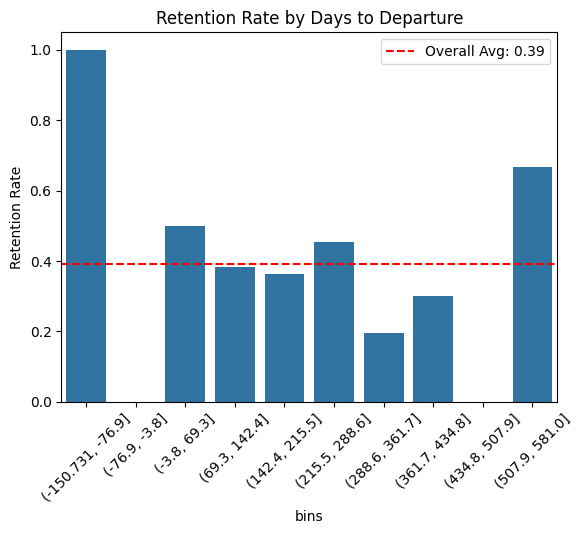

/tmp/ipython-input-148/3359260705.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention_rate = data_feature_section.groupby('bins')['RetainedLabel'].mean().reset_index()


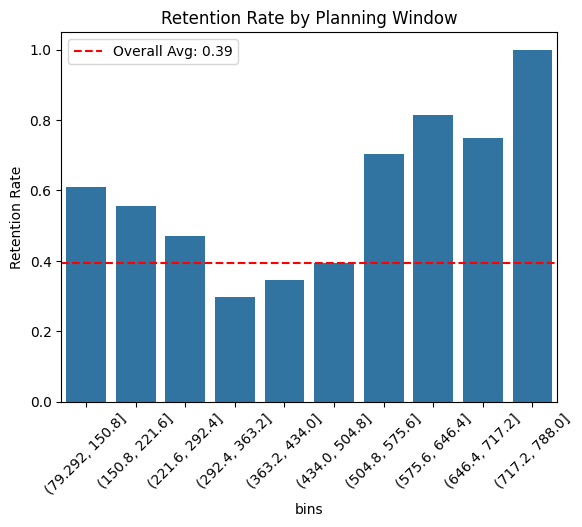

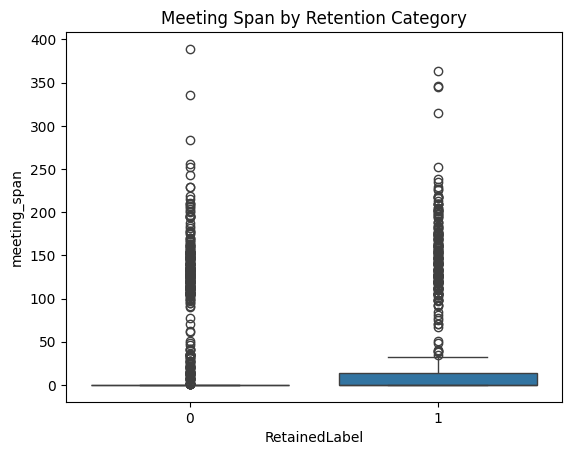

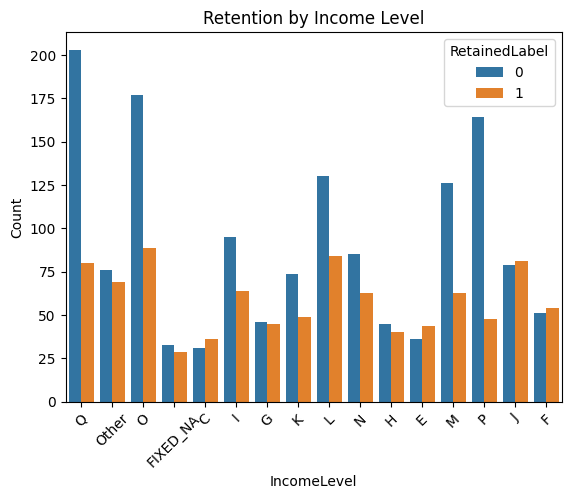

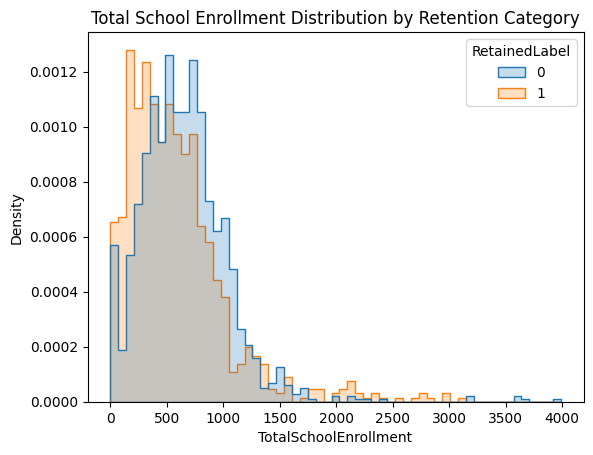

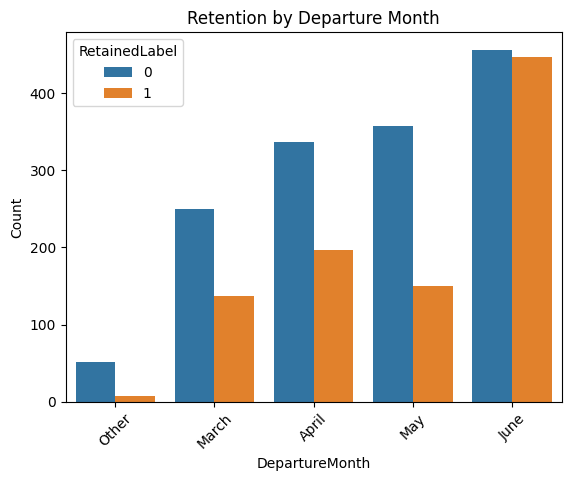

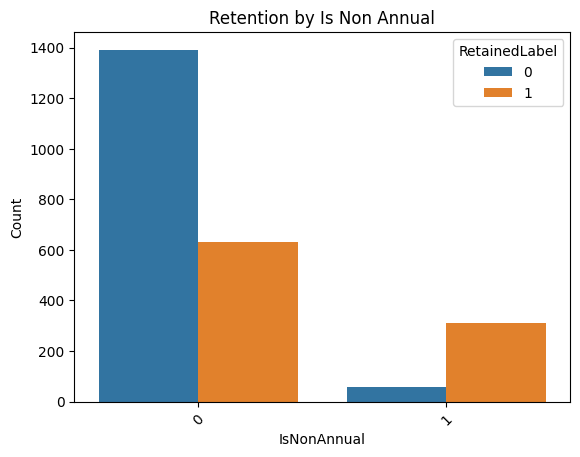

/tmp/ipython-input-148/3359260705.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention_rate = data_feature_section.groupby('bins')['RetainedLabel'].mean().reset_index()


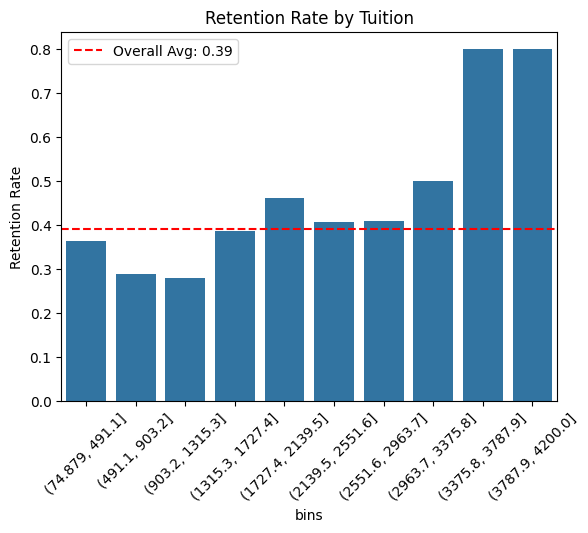

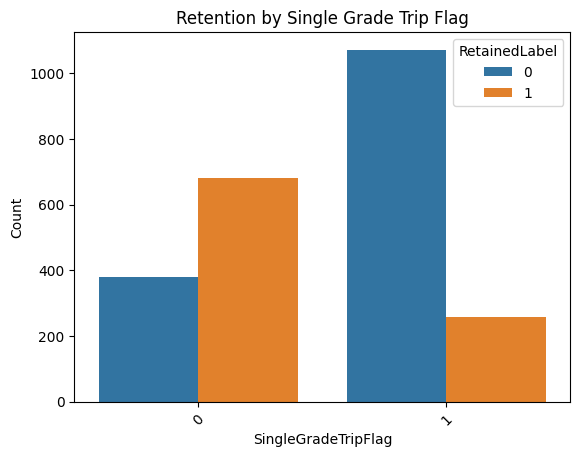

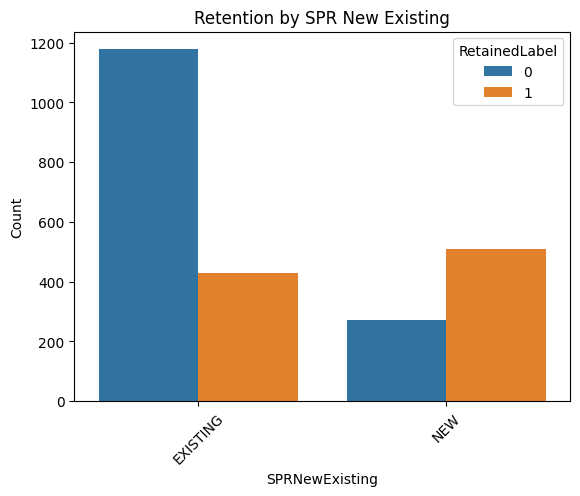

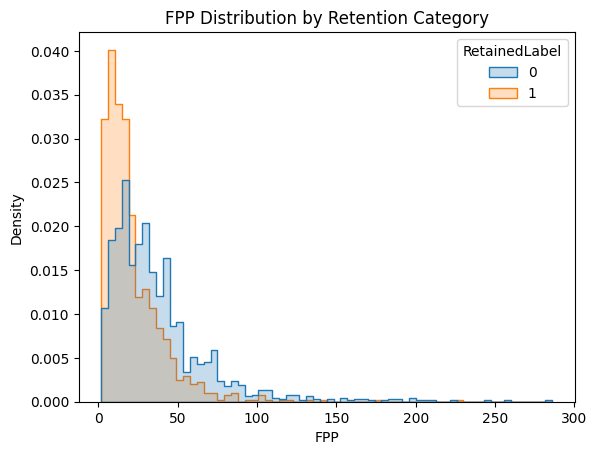

In [37]:
barplot_bin_retention('days_to_departure', 'Days to Departure', 10)

barplot_bin_retention('planning_window', 'Planning Window', 10)

boxplot_retention('meeting_span', 'Meeting Span')

countplot_retention('IncomeLevel', 'Income Level')

histplot_retention('TotalSchoolEnrollment', 'Total School Enrollment')

countplot_retention('DepartureMonth', 'Departure Month')

countplot_retention('IsNonAnnual', 'Is Non Annual')

barplot_bin_retention('Tuition', 'Tuition', 10)

countplot_retention('SingleGradeTripFlag', 'Single Grade Trip Flag')

countplot_retention('SPRNewExisting', 'SPR New Existing')

histplot_retention('FPP', 'FPP')


/tmp/ipython-input-148/3359260705.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention_rate = data_feature_section.groupby('bins')['RetainedLabel'].mean().reset_index()


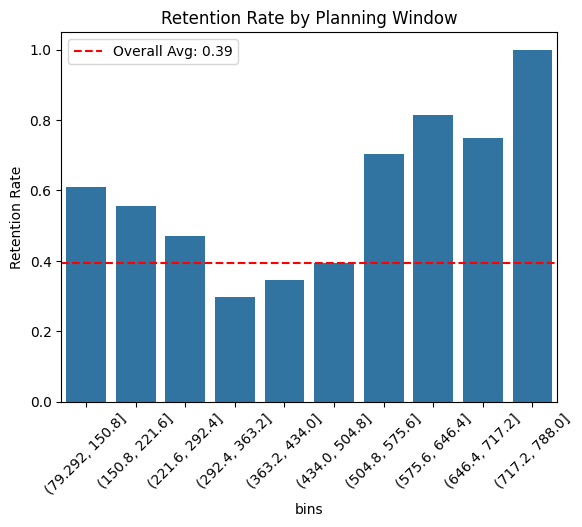

In [38]:
barplot_bin_retention('planning_window', 'Planning Window', 10)

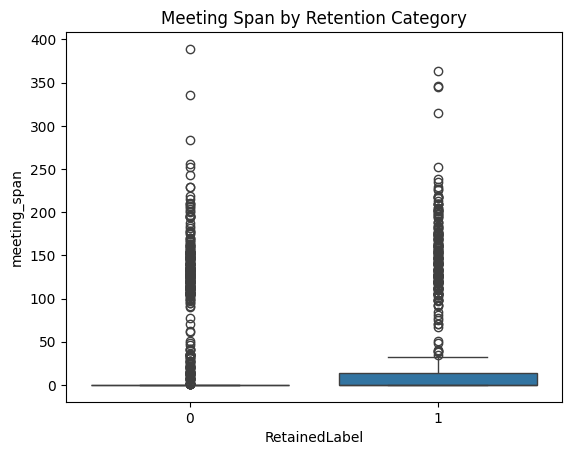

In [39]:
boxplot_retention('meeting_span', 'Meeting Span')

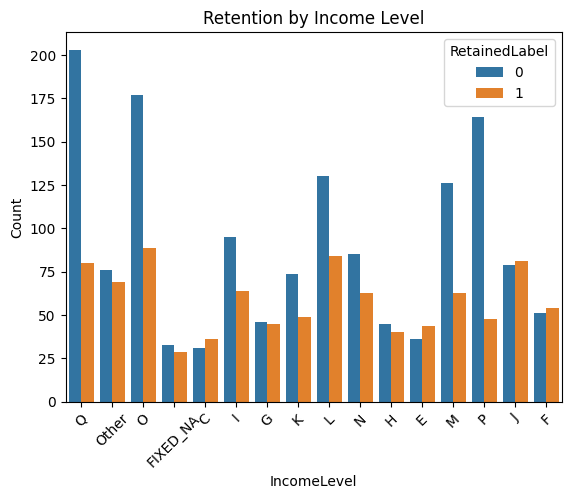

In [40]:
countplot_retention('IncomeLevel', 'Income Level')

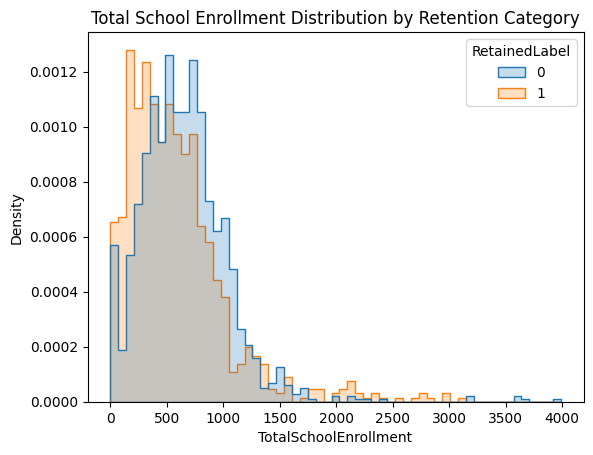

In [41]:
histplot_retention('TotalSchoolEnrollment', 'Total School Enrollment')

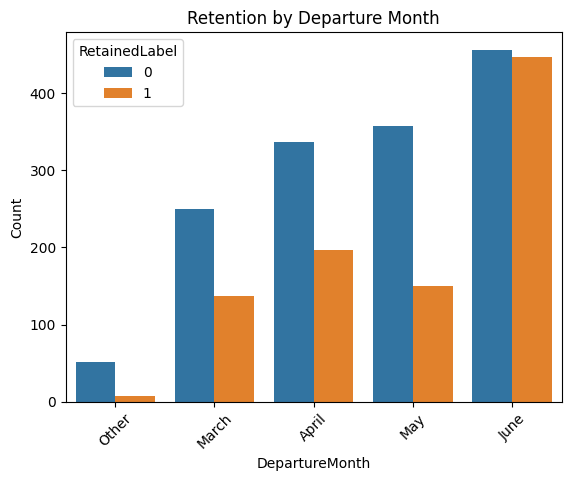

In [42]:
countplot_retention('DepartureMonth', 'Departure Month')

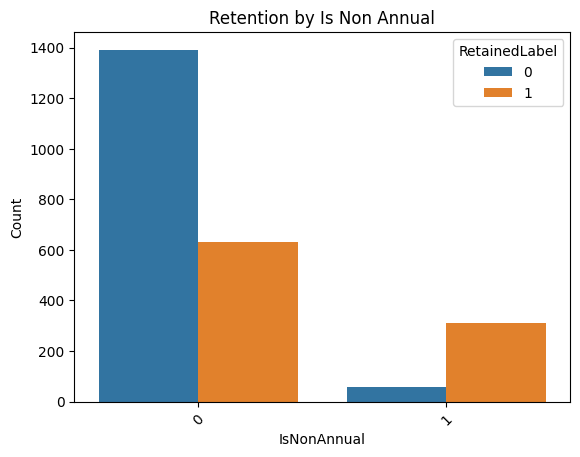

In [43]:
countplot_retention('IsNonAnnual', 'Is Non Annual')

/tmp/ipython-input-148/3359260705.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention_rate = data_feature_section.groupby('bins')['RetainedLabel'].mean().reset_index()


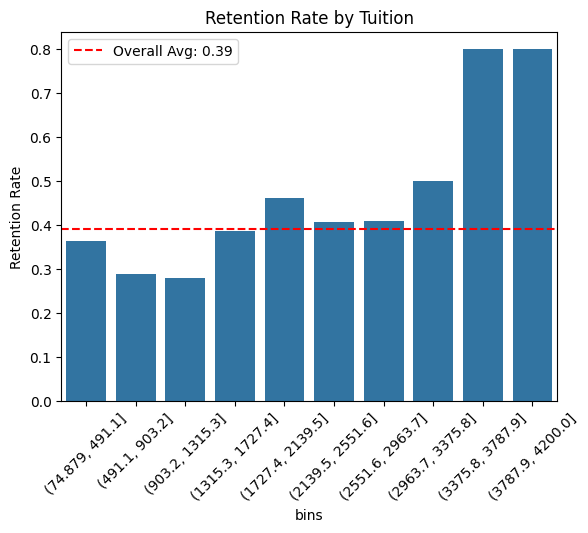

In [44]:
barplot_bin_retention('Tuition', 'Tuition', 10)

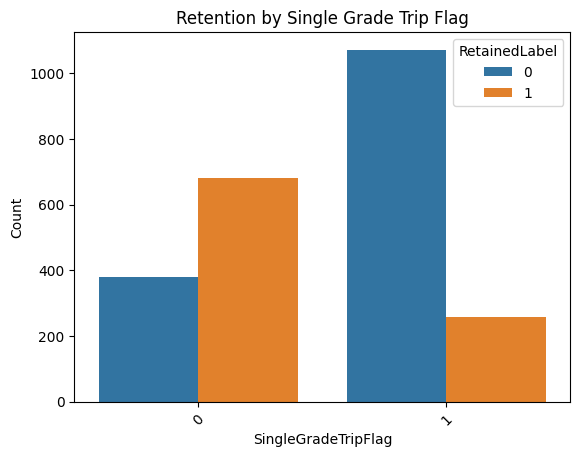

In [45]:
countplot_retention('SingleGradeTripFlag', 'Single Grade Trip Flag')

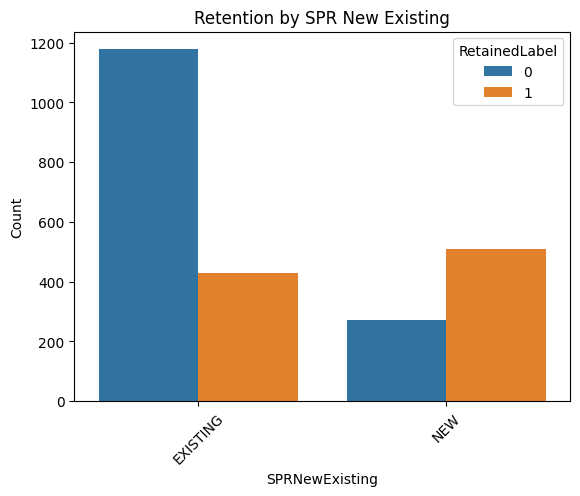

In [46]:
countplot_retention('SPRNewExisting', 'SPR New Existing')

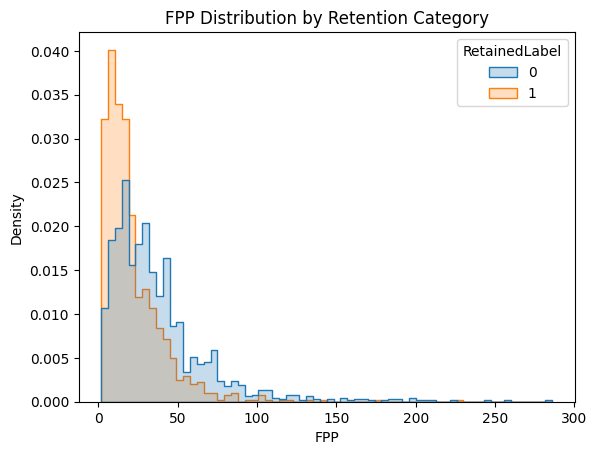

In [47]:
histplot_retention('FPP', 'FPP')

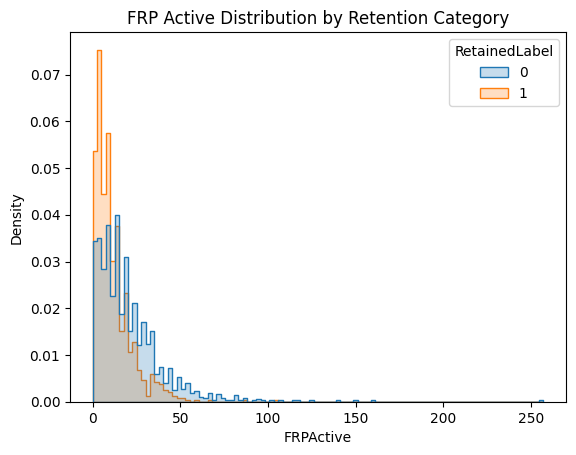

In [48]:
histplot_retention('FRPActive', 'FRP Active')

I chose to select the following columns:
* planning_window
* TotalSchoolEnrollment
* DepartureMonth
* IsNonAnnual
* Tuition
* SingleGradeTripFlag
* SPRNewExisting
* FPP

In [49]:

selected_columns = ["planning_window",
                    "TotalSchoolEnrollment",
                    "DepartureMonth",
                    "IsNonAnnual",
                    "Tuition",
                    "SingleGradeTripFlag",
                    "SPRNewExisting",
                    "FPP",

                    "RetainedLabel"]

data_columns = data[selected_columns]

In [50]:
# Convert categorical features to numerical using one-hot encoding
data_columns = pd.get_dummies(data_columns, drop_first=True)

# Define features (X) and target (y)
X = data_columns.drop("RetainedLabel", axis=1)
y = data_columns["RetainedLabel"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
#limit train size to 1000 so that the model runs faster during the debuging stage
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=1000, stratify=y, random_state=42)

In [51]:
#takes 11 minutes to run
param_grid = {
    "kernel": [
        1.0 * RBF(),
        1.0 * Matern(nu=1.5),
        1.0 * Matern(nu=5.5),
        1.0 * RationalQuadratic()
    ],
    "n_restarts_optimizer": [0, 5]
}

gpc = GaussianProcessClassifier(random_state=42)

grid = GridSearchCV(
    gpc,
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

NameError: name 'RBF' is not defined

In [ ]:
# Define the Gaussian Process kernel
# Kernel = Constant * RBF
kernel = C(1.0) * Matern(length_scale=1, nu=1.5)

# Initialize the Gaussian Process Classifier
gpc = GaussianProcessClassifier(kernel=kernel, random_state=42, n_restarts_optimizer=0)

# Fit the model
gpc.fit(X_train, y_train)

# Make predictions
gpc_y_pred = gpc.predict(X_test)

# Evaluate the model
print("GPC Accuracy:", accuracy_score(y_test, gpc_y_pred))
print("\nGPC Classification Report:\n", classification_report(y_test, gpc_y_pred))

cm = confusion_matrix(y_test, gpc_y_pred)

# Create the confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])

# Plot the confusion matrix
disp.plot(cmap='Blues')
plt.title('GPC Confusion Matrix')
plt.show()

In [ ]:
# Split the data into training and testing sets
#use test_size = 0.2 to fit the model on more of the training data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Define the Gaussian Process kernel
# Kernel = Constant * RBF
kernel = C(1.0) * Matern(length_scale=1, nu=1.5)

# Initialize the Gaussian Process Classifier
gpc = GaussianProcessClassifier(kernel=kernel, random_state=42, n_restarts_optimizer=0)

# Fit the model
gpc.fit(X_train, y_train)

# Make predictions
gpc_y_pred = gpc.predict(X_test)

# Evaluate the model
print("GPC Accuracy:", accuracy_score(y_test, gpc_y_pred))
print("\nGPC Classification Report:\n", classification_report(y_test, gpc_y_pred))

cm = confusion_matrix(y_test, gpc_y_pred)

# Create the confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])

# Plot the confusion matrix
disp.plot(cmap='Blues')
plt.title('GPC Confusion Matrix')
plt.show()

In [ ]:
y_prob = gpc.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)

In [ ]:
# Variable Importance Plot
# Based of permutation importance: shuffle one feature at a time and measure how much model performance drops
# Score based off ROC AUC
result = permutation_importance(
    gpc,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)


importances = pd.Series(result.importances_mean, index=X.columns)
importances = importances.sort_values(ascending=False)

In [ ]:
importances.plot(kind='barh')
plt.xlabel("Mean Decrease in AUC")
plt.title("Permutation Importance - Gaussian Process")
plt.gca().invert_yaxis()
plt.show()

# Making Predictions with the Guassian Model

In [ ]:
# Create the final model using all of the data
# Kernel = Constant * RBF
kernel = C(1.0) * Matern(length_scale=1, nu=1.5)

# Initialize the Gaussian Process Classifier
gpc = GaussianProcessClassifier(kernel=kernel, random_state=42, n_restarts_optimizer=0)

# Fit the model
gpc.fit(X_scaled, y)


In [ ]:
prediction_data = pd.read_csv('https://www.dropbox.com/scl/fi/hveyqinjaurpm2e1s5uh2/scholastic_travel_predictions.csv?rlkey=3sx0cjmaubjafwripmcsfhktd&st=lbb9ii3b&dl=1')

prediction_data.head()

In [ ]:
for col in date_cols:
    prediction_data[col] = pd.to_datetime(prediction_data[col], format="%m/%d/%y", errors="coerce")

In [ ]:
prediction_data["days_to_departure"] = (prediction_data["DepartureDate"] - prediction_data["DepositDate"]).dt.days
prediction_data["planning_window"] = (prediction_data["DepartureDate"] - prediction_data["InitialSystemDate"]).dt.days
prediction_data["meeting_span"] = (prediction_data["LastMeeting"] - prediction_data["FirstMeeting"]).dt.days
prediction_data["deposit_to_first_meeting"] = (prediction_data["FirstMeeting"] - prediction_data["DepositDate"]).dt.days

In [ ]:
prediction_data = prediction_data[selected_columns]

prediction_data = pd.get_dummies(prediction_data, drop_first=True)

X_pred = prediction_data.drop('RetainedLabel', axis=1)

# make sure we have the same columns in this dataset as in training
training_features = X.columns
X_pred = X_pred.reindex(columns=training_features, fill_value=0)

scaler = StandardScaler()
X_pred = scaler.fit_transform(X_pred)

In [ ]:
# Add the predictions to the prediction_data DataFrame
prediction_data['RetainedLabel'] = gpc.predict(X_pred)
mapping = {0: 'Retained', 1: 'Churned'}
data['RetainedLabel'] = data['RetainedLabel'].map(mapping)

In [ ]:
# Save files

prediction_data.to_csv('Classification Project Predictions.csv', index=False)